In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import plot_model

In [2]:
# ============================
# 1. LOAD DATASET
# ============================
df = pd.read_csv("features.csv")
print("Data berhasil dibaca!")
print(df.head())

# Hapus kolom filename (tidak diperlukan untuk training)
X = df.drop(columns=["filename", "label"]).values
y = df["label"].values

Data berhasil dibaca!
                  filename            label    feat_0    feat_1    feat_2  \
0  Alienware 13 R3_001.jpg  Alienware 13 R3 -0.127747 -0.397347 -0.979468   
1  Alienware 13 R3_002.jpg  Alienware 13 R3  0.293418  3.416762  0.480602   
2  Alienware 13 R3_003.jpg  Alienware 13 R3 -0.709516 -0.790797 -0.291266   
3  Alienware 13 R3_004.jpg  Alienware 13 R3 -0.776375 -0.224861 -0.973687   
4  Alienware 13 R3_005.jpg  Alienware 13 R3 -0.794023 -0.863866 -0.982995   

     feat_3    feat_4    feat_5    feat_6    feat_7  ...  feat_196  feat_197  \
0 -0.984375 -0.886999 -0.857776 -0.757680 -0.847360  ...  1.069517 -0.102316   
1 -0.296343 -0.304828 -0.397662 -0.527766 -0.635394  ...  0.009416 -0.829914   
2  0.217011  0.018242  0.029650  0.064431  0.187423  ...  0.179278  0.311250   
3 -1.007049 -0.872140 -0.812006 -0.695489 -0.792054  ... -1.640918  1.052925   
4 -0.990534 -0.890424 -0.735315 -0.637091 -0.718630  ... -0.846196  0.439305   

   feat_198  feat_199  feat_200  f

In [3]:
# ============================
# 2. ENCODE LABEL
# ============================
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)
num_classes = len(np.unique(y_encoded))

print("\nLabel encoding:")
for i, cls in enumerate(encoder.classes_):
    print(f"{i} = {cls}")


Label encoding:
0 = ASUS ROG Strix SCAR 17 (2023)
1 = Alienware 13 R3
2 = Alienware alpha
3 = Alienware m17 R4
4 = Alienware x17 R2
5 = Chromebook 11 3180
6 = Dell G15 5510
7 = Dell XPS 13 9370
8 = Dell m16
9 = ROG Zephyrus G16
10 = XPS 27 7760


In [4]:

# ============================
# 3. NORMALISASI FITUR
# ============================
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [5]:
# ============================
# 4. SPLIT TRAIN/TEST
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42
)

In [6]:
# ============================
# 5. BANGUN MODEL ANN
# ============================
model = Sequential([
    Dense(128, activation='relu', input_dim=X.shape[1]),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          26,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 11)                  │             363 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,195 (145.29 KB)

 Trainable params: 37,195 (145.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# ============================
# 6. TRAIN MODEL
# ============================
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test, y_test)
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3160 - loss: 2.1030 - val_accuracy: 0.3730 - val_loss: 1.9205
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4400 - loss: 1.7101 - val_accuracy: 0.4048 - val_loss: 1.8682
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5100 - loss: 1.4718 - val_accuracy: 0.3333 - val_loss: 1.8913
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6100 - loss: 1.2537 - val_accuracy: 0.4444 - val_loss: 1.8996
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6560 - loss: 1.0925 - val_accuracy: 0.4365 - val_loss: 1.8564
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7220 - loss: 0.9288 - val_accuracy: 0.4603 - val_loss: 1.7473
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7540 - loss: 0.8145 - val_accuracy: 0.4365 - val_loss: 1.7920
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7800 - loss: 0.7169 - val_accuracy: 0.4524 - val_l

In [9]:
# ============================
# 7. EVALUASI MODEL
# ============================
loss, acc = model.evaluate(X_test, y_test)
print(f"\nAkurasi Model: {acc*100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4762 - loss: 3.8031

Akurasi Model: 47.62%


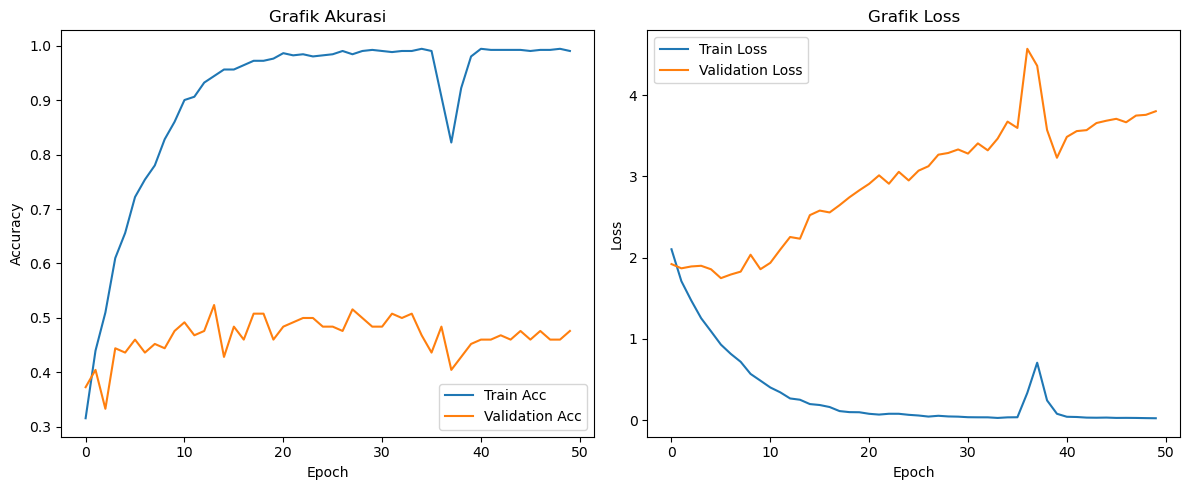

In [10]:
# ============================
# 8. VISUALISASI TRAINING
# ============================
plt.figure(figsize=(12,5))

# Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Validation Acc')
plt.title("Grafik Akurasi")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Grafik Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
# ============================
# 9. SIMPAN MODEL
# ============================
model.save("model/saved_model.h5")
print("\nModel berhasil disimpan ke: model/saved_model.h5")

# Simpan arsitektur
plot_model(model, to_file="model/model_architecture.png", show_shapes=True)
print("Arsitektur model disimpan ke: model/model_architecture.png")

print("\n=== Training Selesai ===")


Model berhasil disimpan ke: model/saved_model.h5
You must install pydot (`pip install pydot`) for `plot_model` to work.
Arsitektur model disimpan ke: model/model_architecture.png

=== Training Selesai ===


In [12]:
from tensorflow.keras.models import load_model

# Load model
model = load_model("model/saved_model.h5")

# Tampilkan informasi model
model.summary()

print("Model berhasil dibuka!")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          26,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 11)                  │             363 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,197 (145.30 KB)

 Trainable params: 37,195 (145.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Model berhasil dibuka!
